In [500]:
import geopandas as gpd
import shapely
from shapely import Point, LineString, Polygon

#### Getting at coordinates

In [501]:
p,q,r = Point(1,1),Point(2,1),Point(2,2)
p.x

1.0

In [502]:
p.xy

(array('d', [1.0]), array('d', [1.0]))

In [503]:
type(p.xy)

tuple

shapely has `coords`

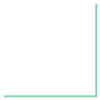

In [504]:
LS = LineString([p,q,r])
LS

In [505]:
LS.coords

In [506]:
LS.coords.xy

(array('d', [1.0, 2.0, 2.0]), array('d', [1.0, 1.0, 2.0]))

In [507]:
L = list(LS.coords.xy[1])
L

[1.0, 1.0, 2.0]

In [508]:
type(L[0])

float

In [509]:
gs = gpd.GeoSeries(LS)
gs

0    LINESTRING (1 1, 2 1, 2 2)
dtype: geometry

In [510]:
len(gs)

1

In [511]:
geo = gs.geometry
geo

0    LINESTRING (1 1, 2 1, 2 2)
dtype: geometry

In [512]:
type(geo)

geopandas.geoseries.GeoSeries

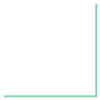

In [513]:
geo.iloc[0]

In [514]:
type(geo.iloc[0])

shapely.geometry.linestring.LineString

In [515]:
df = geo.get_coordinates()
df

,x,y
0,1.0,1.0
0,2.0,1.0
0,2.0,2.0


In [516]:
type(df)

pandas.core.frame.DataFrame

In [517]:
df['x']

0    1.0
0    2.0
0    2.0
Name: x, dtype: float64

In [518]:
type(df['x'])

pandas.core.series.Series

In [519]:
type(df['x'][0])

pandas.core.series.Series

In [520]:
df['x'][0]

0    1.0
0    2.0
0    2.0
Name: x, dtype: float64

In [521]:
df['x'][0][0][0]

0    1.0
0    2.0
0    2.0
Name: x, dtype: float64

Index as many times as you want, you'll still have a series.  Do `list` first.

In [522]:
L = list(df['x'])
L

[1.0, 2.0, 2.0]

In [523]:
type(L[0])

float

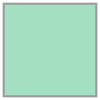

In [524]:
pg = Polygon([p,q,r,Point(1,2),p])
pg

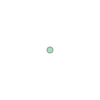

In [525]:
pg.centroid

In [526]:
print(pg.centroid)

POINT (1.5 1.5)


In [527]:
type(pg.centroid)

shapely.geometry.point.Point

In [528]:
print(pg.representative_point())

POINT (1.5 1.5)


A representative point is *cheaply computed*:

In [529]:
print(LS.centroid,LS.representative_point())

POINT (1.75 1.25) POINT (2 1)


In [530]:
pg.exterior.coords

The polygon is constructed from its vertices, but `coords` only makes sense for the `exterior`.  GeoPandas does not use `coords`.

In [531]:
gs = gpd.GeoSeries(pg)
gs

0    POLYGON ((1 1, 2 1, 2 2, 1 2, 1 1))
dtype: geometry

Both `gs` and `gs.geometry` are GeoSeries and `get_coordinates()` gives same result for both.

In [532]:
geo = gs.geometry
geo.get_coordinates()

,x,y
0,1.0,1.0
0,2.0,1.0
0,2.0,2.0
0,1.0,2.0
0,1.0,1.0


In [533]:
type(gs.iloc[0])

shapely.geometry.polygon.Polygon

In [534]:
type(geo.iloc[0])

shapely.geometry.polygon.Polygon

In [535]:
gs.iloc[0].exterior.coords

We are back to a shapely object.

In [536]:
D = {}
gdf = gpd.GeoDataFrame(D,geometry=gs)
gdf.geometry

0    POLYGON ((1 1, 2 1, 2 2, 1 2, 1 1))
Name: geometry, dtype: geometry

In [537]:
gdf.geometry.get_coordinates()

,x,y
0,1.0,1.0
0,2.0,1.0
0,2.0,2.0
0,1.0,2.0
0,1.0,1.0
